**Canny Edge using BuiltIn Function**

In [ ]:
import cv2  
  
img = cv2.imread("D:hsv.png")
t_lower = 100  
t_upper = 200 
aperture_size = 5 
L2Gradient = True 
edge = cv2.Canny(img, t_lower, t_upper, 
                 apertureSize = aperture_size,  
                 L2gradient = L2Gradient )  
  
cv2.imshow('original', img) 
cv2.imshow('edge', edge) 
cv2.waitKey(0) 
cv2.destroyAllWindows()

**Canny Edge without BuiltIn Function**

(-0.5, 1279.5, 719.5, -0.5)

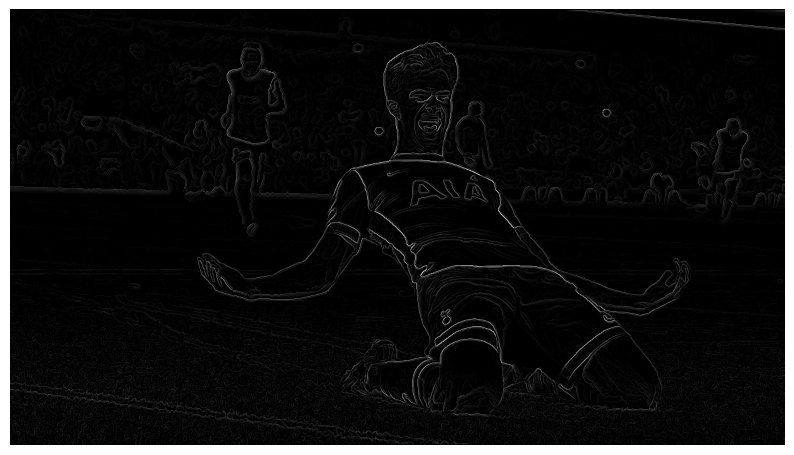

In [11]:
import numpy as np 
import os 
import cv2 
import matplotlib.pyplot as plt 
def Canny_detector(img, weak_th = None, strong_th = None): 
	
	img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)  
	img = cv2.GaussianBlur(img, (5, 5), 1.4) 
	gx = cv2.Sobel(np.float32(img), cv2.CV_64F, 1, 0, 3) 
	gy = cv2.Sobel(np.float32(img), cv2.CV_64F, 0, 1, 3) 
	mag, ang = cv2.cartToPolar(gx, gy, angleInDegrees = True) 
	mag_max = np.max(mag) 
	if not weak_th:weak_th = mag_max * 0.1
	if not strong_th:strong_th = mag_max * 0.5
	height, width = img.shape 
	for i_x in range(width): 
		for i_y in range(height): 
			grad_ang = ang[i_y, i_x] 
			grad_ang = abs(grad_ang-180) if abs(grad_ang)>180 else abs(grad_ang) 
			if grad_ang<= 22.5: 
				neighb_1_x, neighb_1_y = i_x-1, i_y 
				neighb_2_x, neighb_2_y = i_x + 1, i_y 
			elif grad_ang>22.5 and grad_ang<=(22.5 + 45): 
				neighb_1_x, neighb_1_y = i_x-1, i_y-1
				neighb_2_x, neighb_2_y = i_x + 1, i_y + 1
			elif grad_ang>(22.5 + 45) and grad_ang<=(22.5 + 90): 
				neighb_1_x, neighb_1_y = i_x, i_y-1
				neighb_2_x, neighb_2_y = i_x, i_y + 1
			elif grad_ang>(22.5 + 90) and grad_ang<=(22.5 + 135): 
				neighb_1_x, neighb_1_y = i_x-1, i_y + 1
				neighb_2_x, neighb_2_y = i_x + 1, i_y-1
			elif grad_ang>(22.5 + 135) and grad_ang<=(22.5 + 180): 
				neighb_1_x, neighb_1_y = i_x-1, i_y 
				neighb_2_x, neighb_2_y = i_x + 1, i_y 
			if width>neighb_1_x>= 0 and height>neighb_1_y>= 0: 
				if mag[i_y, i_x]<mag[neighb_1_y, neighb_1_x]: 
					mag[i_y, i_x]= 0
					continue
			if width>neighb_2_x>= 0 and height>neighb_2_y>= 0: 
				if mag[i_y, i_x]<mag[neighb_2_y, neighb_2_x]: 
					mag[i_y, i_x]= 0
	weak_ids = np.zeros_like(img) 
	strong_ids = np.zeros_like(img)			 
	ids = np.zeros_like(img) 
	for i_x in range(width): 
		for i_y in range(height): 
			grad_mag = mag[i_y, i_x] 
			if grad_mag<weak_th: 
				mag[i_y, i_x]= 0
			elif strong_th>grad_mag>= weak_th: 
				ids[i_y, i_x]= 1
			else: 
				ids[i_y, i_x]= 2 
	return mag 
    
frame = cv2.imread('D:berg.png')
canny_img = Canny_detector(frame,weak_th=10,strong_th=220)
plt.figure(figsize=(10,10)) 
plt.imshow(canny_img,cmap='gray')
plt.axis('off')

**Laplacian of Gaussian 1**

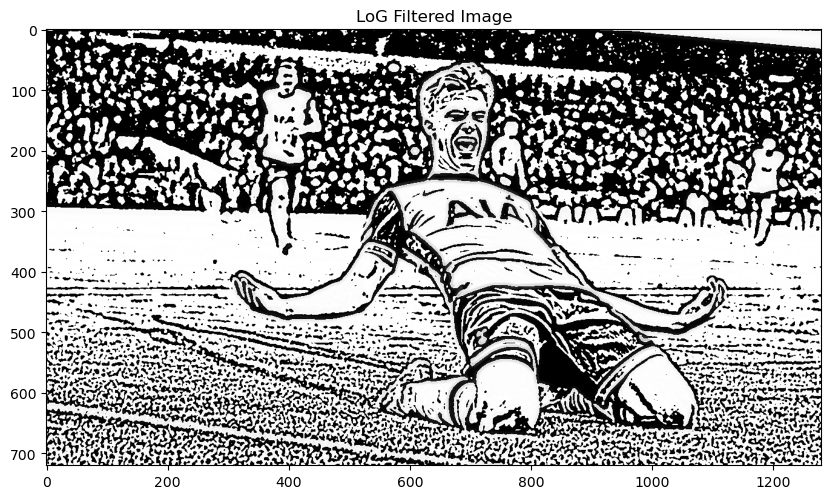

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import convolve
from scipy import misc

def LoG_filter(image, sigma, size=None):
    if size is None:
        size = int(6 * sigma + 1) if sigma >= 1 else 7

    if size % 2 == 0:
        size += 1

    x, y = np.meshgrid(np.arange(-size//2+1, size//2+1), np.arange(-size//2+1, size//2+1))
    kernel = -(1/(np.pi * sigma**4)) * (1 - ((x**2 + y**2) / (2 * sigma**2))) * np.exp(-(x**2 + y**2) / (2 * sigma**2))
    kernel = kernel / np.sum(np.abs(kernel))
    result = convolve(image, kernel)
    return result

image = cv2.imread(r"D:berg.png", cv2.IMREAD_GRAYSCALE)  
sigma = 2.0
filtered_image = LoG_filter(image, sigma)
plt.figure(figsize=(10, 10))
'''plt.subplot(121)
plt.imshow(image, cmap='gray')
plt.title('Original Image')

plt.subplot(122)'''
plt.imshow(filtered_image, cmap='gray')
plt.title('LoG Filtered Image')

plt.show()

**Laplacian of Gaussian 2**

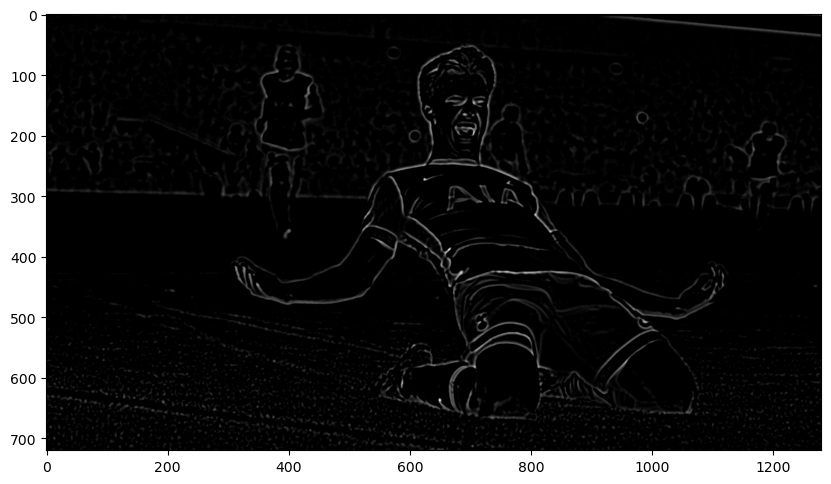

In [25]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
def LoG_filter_opencv(image, sigma, size=None):
    if size is None:
        size = int(6 * sigma + 1) if sigma >= 1 else 7

    if size % 2 == 0:
        size += 1

    x, y = np.meshgrid(np.arange(-size//2+1, size//2+1), np.arange(-size//2+1, size//2+1))
    kernel = -(1/(np.pi * sigma**4)) * (1 - ((x**2 + y**2) / (2 * sigma**2))) * np.exp(-(x**2 + y**2) / (2 * sigma**2))
    kernel = kernel / np.sum(np.abs(kernel))
    result = cv2.filter2D(image, -1, kernel)
    return result

plt.figure(figsize=(10,10))
image = cv2.imread(r"D:berg.png", cv2.IMREAD_GRAYSCALE)  
sigma = 2.0
filtered_image = LoG_filter_opencv(image, sigma)
filtered_image = cv2.convertScaleAbs(filtered_image)
plt.imshow(filtered_image, cmap="gray")

**Difference of Gaussian**

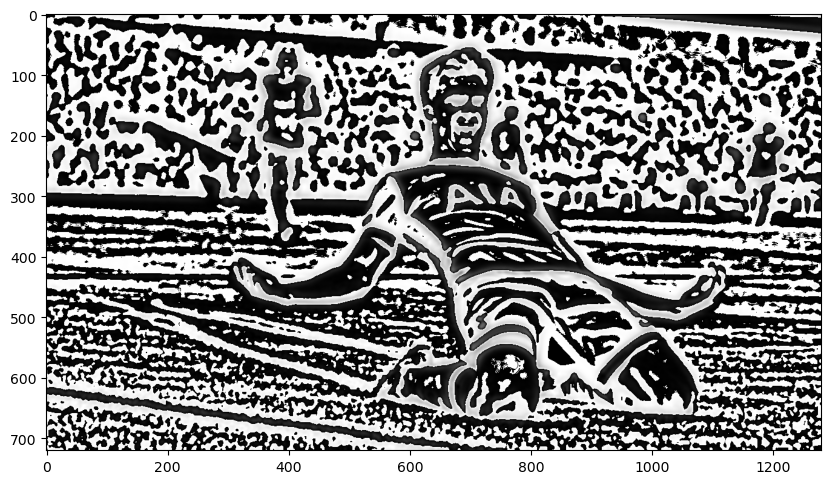

In [41]:
import cv2
import numpy as np

def DoG_filter_opencv(image, sigma1, sigma2, size=None):
    if size is None:
        size = int(6 * max(sigma1, sigma2) + 1) if max(sigma1, sigma2) >= 1 else 7
    if size % 2 == 0:
        size += 1
    gaussian1 = cv2.GaussianBlur(image, (size, size), sigma1)
    gaussian2 = cv2.GaussianBlur(image, (size, size), sigma2)
    result = gaussian1 - gaussian2
    return result
plt.figure(figsize=(10,10))
image = cv2.imread(r"D:berg.png", cv2.IMREAD_GRAYSCALE) 
sigma = 2.0
sigma2= 7.0
filtered_image = DoG_filter_opencv(image, sigma,sigma2)
filtered_image = cv2.convertScaleAbs(filtered_image)
plt.imshow(filtered_image, cmap="gray")

**Roberts Filter**

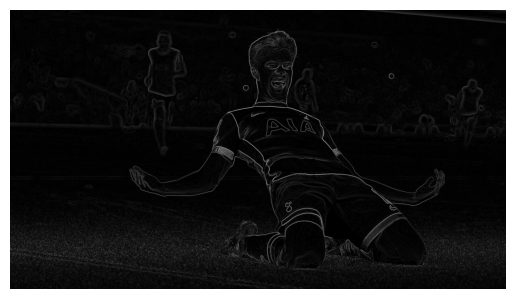

In [63]:
import cv2  
import numpy as np 
from scipy import ndimage
import matplotlib.pyplot as plt 
roberts_cross_v = np.array([[1, 0], [0, -1]])  
roberts_cross_h = np.array([[0, 1], [-1, 0]])
img = cv2.imread("D:/berg.png", cv2.IMREAD_GRAYSCALE).astype('float64')
img /= 255.0
vertical = ndimage.convolve(img, roberts_cross_v)
horizontal = ndimage.convolve(img, roberts_cross_h)
edged_img = np.sqrt(np.square(horizontal) + np.square(vertical))
edged_img *= 255
plt.imshow(edged_img, cmap='gray')
plt.axis('off') 
plt.show()


**Scharr Filter**

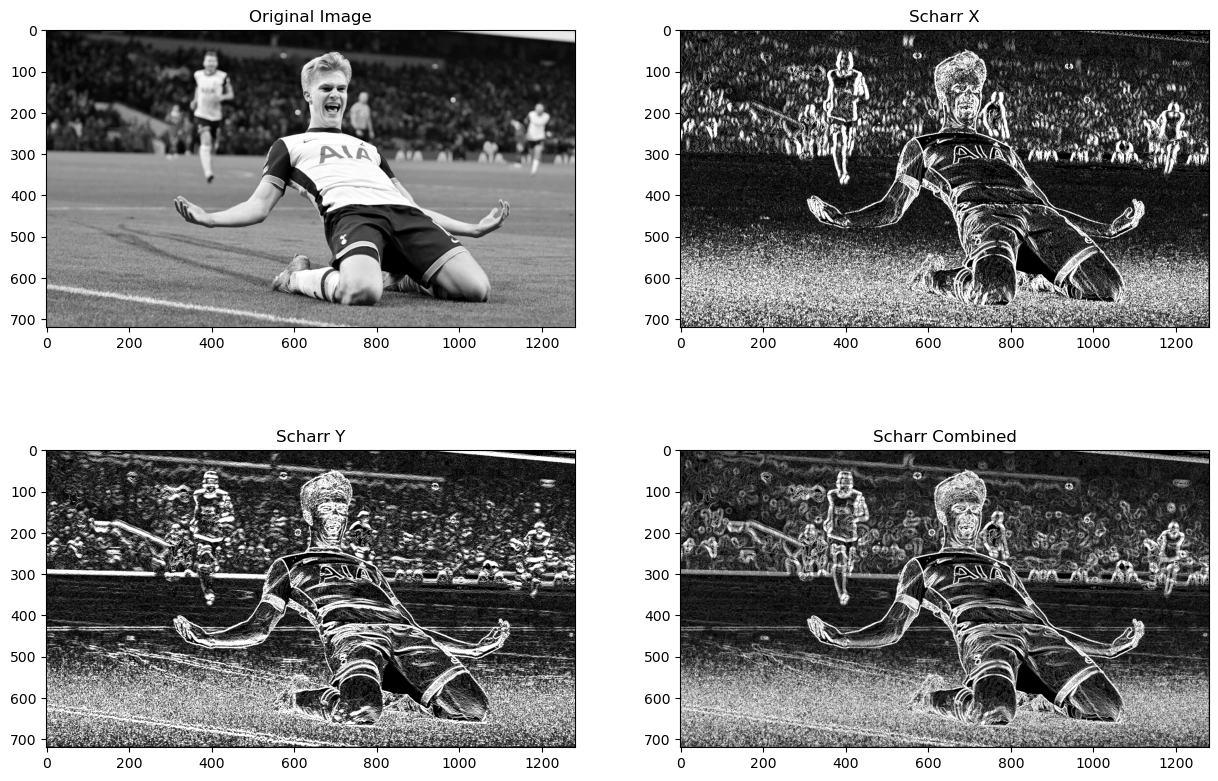

In [81]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
image = cv2.imread('D:berg.png', cv2.IMREAD_GRAYSCALE)
scharr_x = cv2.Scharr(image, cv2.CV_64F, 1, 0)
scharr_y = cv2.Scharr(image, cv2.CV_64F, 0, 1)
scharr_x = cv2.convertScaleAbs(scharr_x)
scharr_y = cv2.convertScaleAbs(scharr_y)
scharr_combined = cv2.addWeighted(scharr_x, 0.5, scharr_y, 0.5, 0)
plt.figure(figsize=(15, 20))
plt.subplot(2, 2, 1)
plt.title('Original Image')
plt.imshow(image, cmap='gray')
plt.subplot(2, 2, 2)
plt.title('Scharr X')
plt.imshow(scharr_x, cmap='gray')
plt.subplot(1, 2, 1)
plt.title('Scharr Y')
plt.imshow(scharr_y, cmap='gray')
plt.subplot(1, 2, 2)
plt.title('Scharr Combined')
plt.imshow(scharr_combined, cmap='gray')
plt.show()


**Prewitt Filter**

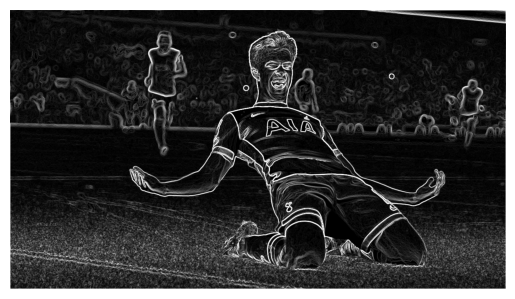

In [93]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
Px = np.array([[-1, 0, 1],
               [-1, 0, 1],
               [-1, 0, 1]])

Py = np.array([[-1, -1, -1],
               [ 0,  0,  0],
               [ 1,  1,  1]])
def convolution(image, kernel):
    img_height, img_width = image.shape
    kernel_height, kernel_width = kernel.shape
    output = np.zeros_like(image)
    pad_height = kernel_height // 2
    pad_width = kernel_width // 2
    padded_image = np.pad(image, ((pad_height, pad_height), (pad_width, pad_width)), mode='constant', constant_values=0)

    for i in range(img_height):
        for j in range(img_width):
            roi = padded_image[i:i + kernel_height, j:j + kernel_width]
            output[i, j] = np.sum(roi * kernel)
    
    return output

img = cv2.imread('D:/berg.png', cv2.IMREAD_GRAYSCALE)
img = img.astype(np.float32)
img /= 255.0
horizontal_gradient = convolution(img, Px)
vertical_gradient = convolution(img, Py)

edge_magnitude = np.sqrt(np.square(horizontal_gradient) + np.square(vertical_gradient))
edge_magnitude = np.clip(edge_magnitude * 255, 0, 255)
edge_magnitude = edge_magnitude.astype(np.uint8)
plt.imshow(edge_magnitude, cmap='gray')
plt.axis('off')
plt.show()
